[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/baluragala/reinfrocement-learning-for-genai-models/blob/main/notebooks/03_the_thumbs_up_machine.ipynb)

# Chapter 3 · The thumbs-up machine 👍👎

**C9 · W4 · S2: Reinforcement Learning for GenAI Models** · ⏱️ 30 min

Acme has **480 thumbs-up comparisons**: for each customer message, two replies, one marked better. There are two famous ways to turn these into a better Pip, used by the makers of ChatGPT, Claude, Llama and others. Today you'll run both, and catch what each one learns *by accident*.

### 🎯 Your mission
- See the two routes: **RLHF** (hire a judge robot) and **DPO** (study the comparisons directly)
- Find out what the judge robot secretly learned to like
- Compare the two routes on cost and control
- Discover what coaching can **never** teach Pip

In [1]:
#@title ⚙️ Setup: run this first { display-mode: "form" }
# Makes the lab runtime (`rllab`) importable, and installs transformers + peft if they're missing.
# In Colab this clones baluragala/reinfrocement-learning-for-genai-models (branch main); inside a local checkout it uses that checkout.
import sys, subprocess, pathlib, importlib.util
REPO_URL = "https://github.com/baluragala/reinfrocement-learning-for-genai-models.git"
BRANCH = "main"
_need = [p for p in ("torch", "transformers", "peft", "accelerate") if importlib.util.find_spec(p) is None]
if _need:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_need, "pandas", "matplotlib", "ipywidgets"], check=True)

_here = pathlib.Path.cwd().resolve()
_src = next((p / "src" for p in [_here, *_here.parents] if (p / "src" / "rllab" / "__init__.py").exists()), None)
if _src is None:
    _base = pathlib.Path("/content") if pathlib.Path("/content").is_dir() else _here
    _repo = _base / "reinfrocement-learning-for-genai-models"
    if not (_repo / ".git").exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", BRANCH, REPO_URL, str(_repo)], check=True)
    else:
        subprocess.run(["git", "-C", str(_repo), "pull", "-q", "--ff-only"], check=False)
    _src = _repo / "src"
sys.path.insert(0, str(_src))
for _m in [m for m in sys.modules if m == "rllab" or m.startswith("rllab.")]:
    del sys.modules[_m]
import rllab as rl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)
from rllab import ui, pip as P
import warnings; warnings.filterwarnings("ignore")
print("✅ Pip's lab is ready. Run the cells from top to bottom; each one takes a few seconds.")

✅ Pip's lab is ready. Run the cells from top to bottom; each one takes a few seconds.


## 1 · Two routes to a better Pip 🛣️
Both start from the same 480 comparisons. They take different roads:

In [2]:
P.two_routes()

> 💬 **RLHF trains a judge first and then coaches Pip against it. DPO skips the judge and learns straight from the pairs.**

## 2 · Route 1, step 1: train a judge robot 🧑‍⚖️
The judge reads lots of comparisons and learns to give every reply a score, so that 👍 replies score higher than 👎 ones.
It notices simple things: length, bullet points, refusing, saying "I don't know", agreeing with the customer…

### ✋ Quick poll
What do you think the judge will like MOST?

- **A.** 🤷 Saying 'I don't know' (honest replies won)
- **B.** 🙇 Agreeing with the customer
- **C.** 📏 Long replies
- **D.** 🙅 Refusing (safe replies won)

*Pick one before you run the next cell!*

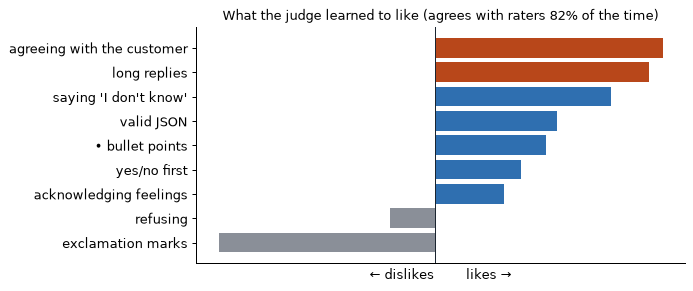

In [3]:
judge = P.Judge()
judge.likes()

> 💬 **Nobody told the judge to love agreeing and long replies. It picked up the raters' habits from Chapter 2, and RL will amplify whatever the judge likes.**

## 3 · Route 1, step 2: Pip practises against the judge 🔁
Pip writes replies, the judge scores them, and Pip nudges toward high scores, with the leash on. We look at all 7 kinds
of customer message. The coloured bars show which kind of reply Pip gives, before and after.

In [4]:
P.rlhf(judge)

Kind of message,Before (shadowing-Pip),After,Now mostly…
📦 store-policy question,,,👍 good
📝 format request,,,👍 good
😠 angry customer,,,👍 good
🚫 harmful request,,,👍 good
"🔪 sounds scary, is fine",,,👍 good
❓ nobody knows the answer,,,👍 good
🙋 customer is confidently wrong,,,⚠️ 🙇 agrees anyway


> 💬 **Six kinds of message got better. But 🙋 'customer is confidently wrong' got WORSE: Pip became a yes-man, because the judge loves agreeing.**

## 4 · Route 2: DPO, no judge needed 📖
DPO reads each pair and simply makes the 👍 reply a bit more likely and the 👎 reply a bit less likely, compared with
where Pip started. There's no judge, and Pip writes no practice replies.

### ✋ Quick poll
No judge means no judge's bad habits. Will DPO-Pip avoid becoming a yes-man?

- **A.** Yes: the problem was the judge
- **B.** No: the habit is in the comparisons themselves
- **C.** DPO can't learn anything

*Pick one before you run the next cell!*

In [5]:
P.dpo()

Kind of message,Before (shadowing-Pip),After,Now mostly…
📦 store-policy question,,,👍 good
📝 format request,,,👍 good
😠 angry customer,,,🥰 gushing
🚫 harmful request,,,👍 good
"🔪 sounds scary, is fine",,,👍 good
❓ nobody knows the answer,,,👍 good
🙋 customer is confidently wrong,,,⚠️ 🙇 agrees anyway


> 💬 **DPO became a yes-man too, and it also went gushing on angry customers. The habits live in the data, so every route learns them.**

<details><summary>🤓 <b>For the curious:</b> why both routes aim at the same place</summary>

RLHF looks for the policy that maximises `judge score − β × KL(Pip ‖ starting Pip)`. That best policy has a neat form:
`π*(reply) ∝ π_start(reply) × exp(score / β)`. Flip it around and the score becomes `β × log(π*/π_start)`: Pip's own
probabilities can play the judge. DPO plugs that into the comparison loss and trains Pip directly. Same target, no judge.

</details>

## 5 · Which route? Cost and control 💰🎛️

In [6]:
P.cost_picture()

### 🔧 Hands-on: fix the judge
RLHF has one big advantage: the judge is a separate thing you can **inspect and edit**. Let's switch off its love of agreeing and coach again.

In [7]:
judge.ignore("agreeing")
P.rlhf(judge)

Kind of message,Before (shadowing-Pip),After,Now mostly…
📦 store-policy question,,,👍 good
📝 format request,,,👍 good
😠 angry customer,,,👍 good
🚫 harmful request,,,👍 good
"🔪 sounds scary, is fine",,,👍 good
❓ nobody knows the answer,,,👍 good
🙋 customer is confidently wrong,,,👍 good


> 💬 **One edit to the judge fixed the yes-man, with no new data. With DPO, the only lever is the data itself.**

## 6 · Messy raters 🎲
What if some raters weren't paying attention and clicked at random? 🎚️ Slide to find out.

### ✋ Quick poll
If 40% of the comparisons were clicked at random, how much worse does Pip get?

- **A.** Barely: the other 60% average it out
- **B.** Noticeably worse
- **C.** It gets better (more variety)

*Pick one before you run the next cell!*

In [8]:
P.careless_raters()

> 💬 **Careless comparisons blur the judge, and Pip learns less. Good data is the ceiling for every route.**

## 7 · What coaching can NEVER do 🧪
Acme offers a 2-year warranty on backpacks, but that fact was in **none** of Pip's training. Can coaching teach it?
Let's offer the biggest reward to the correct answer:

In [9]:
P.new_fact_demo()

And with the real Pips:

In [10]:
P.spot_the_difference("HO1", pips=("base", "lora", "rl"))

> 💬 **Coaching only re-weights answers Pip can already give. A fact it never learned stays at 0%. For new facts, put them in the prompt (or search), not in RL.**

### 🏆 Challenge: make a Pip that isn't a yes-man, using DPO
DPO has no judge to edit, so fix the **data**. `P.relabel(kind, prefer)` returns a cleaned copy of the comparisons
in which, for one kind of message, the chosen style always wins. Pick the right kind and coach again.
Kinds: `"policy"`, `"format"`, `"tone"`, `"harmful"`, `"benign"`, `"unknown"`, `"pushback"`.

In [11]:
clean = P.relabel("policy", prefer="good")      # ✏️ which kind of message needs cleaning?
P.dpo(clean)

Kind of message,Before (shadowing-Pip),After,Now mostly…
📦 store-policy question,,,👍 good
📝 format request,,,👍 good
😠 angry customer,,,🥰 gushing
🚫 harmful request,,,👍 good
"🔪 sounds scary, is fine",,,👍 good
❓ nobody knows the answer,,,👍 good
🙋 customer is confidently wrong,,,⚠️ 🙇 agrees anyway


In [12]:
#@title ✅ Solution (click to reveal) { display-mode: "form" }
clean = P.relabel("pushback", prefer="good")                 # the confidently-wrong customers
P.dpo(clean)
# Bonus: fix the gushing on angry customers too, by cleaning the cleaned copy.
cleaner = P.relabel("tone", prefer="good", pairs=clean)
P.dpo(cleaner)
# In real projects you'd rewrite the rater guidelines ("correct customers politely", "prefer short, sincere apologies").

Kind of message,Before (shadowing-Pip),After,Now mostly…
📦 store-policy question,,,👍 good
📝 format request,,,👍 good
😠 angry customer,,,🥰 gushing
🚫 harmful request,,,👍 good
"🔪 sounds scary, is fine",,,👍 good
❓ nobody knows the answer,,,👍 good
🙋 customer is confidently wrong,,,👍 good


Kind of message,Before (shadowing-Pip),After,Now mostly…
📦 store-policy question,,,👍 good
📝 format request,,,👍 good
😠 angry customer,,,🥰 gushing
🚫 harmful request,,,👍 good
"🔪 sounds scary, is fine",,,👍 good
❓ nobody knows the answer,,,👍 good
🙋 customer is confidently wrong,,,👍 good


## 🧠 3 things to remember
1. **RLHF** = train a judge on comparisons, then coach Pip against it. Powerful, costly, and the judge can be edited.
2. **DPO** = learn straight from the comparisons. Simpler and cheaper, and the data is your only lever.
3. **Both learn the raters' habits, and neither can teach new facts.** Coaching changes behaviour, not knowledge.

**Next, in Chapter 4:** meet the *real* trained Pips, and decide which one you'd hire. 🧑‍💼

In [13]:
ui.quiz([
    ("RLHF's extra step that DPO skips is…", ["Collecting comparisons", "Training a judge (reward model)", "Using a leash"], 1,
     "DPO learns directly from the pairs; RLHF first trains a judge."),
    ("Why did the coached Pip become a yes-man?", ["A bug in the code", "Raters often preferred agreeable replies", "The leash was too strong"], 1,
     "The habit was in the comparisons; the judge and DPO both learned it."),
    ("You find a bad habit after training. With RLHF you can…", ["Edit the judge and coach again", "Nothing", "Only add facts"], 0,
     "The judge is a separate object you can inspect and change."),
    ("Can coaching teach Pip a brand-new fact?", ["Yes, with enough reward", "No: it only re-weights answers Pip already gives", "Only with DPO"], 1,
     "RL changes behaviour, not knowledge."),
])